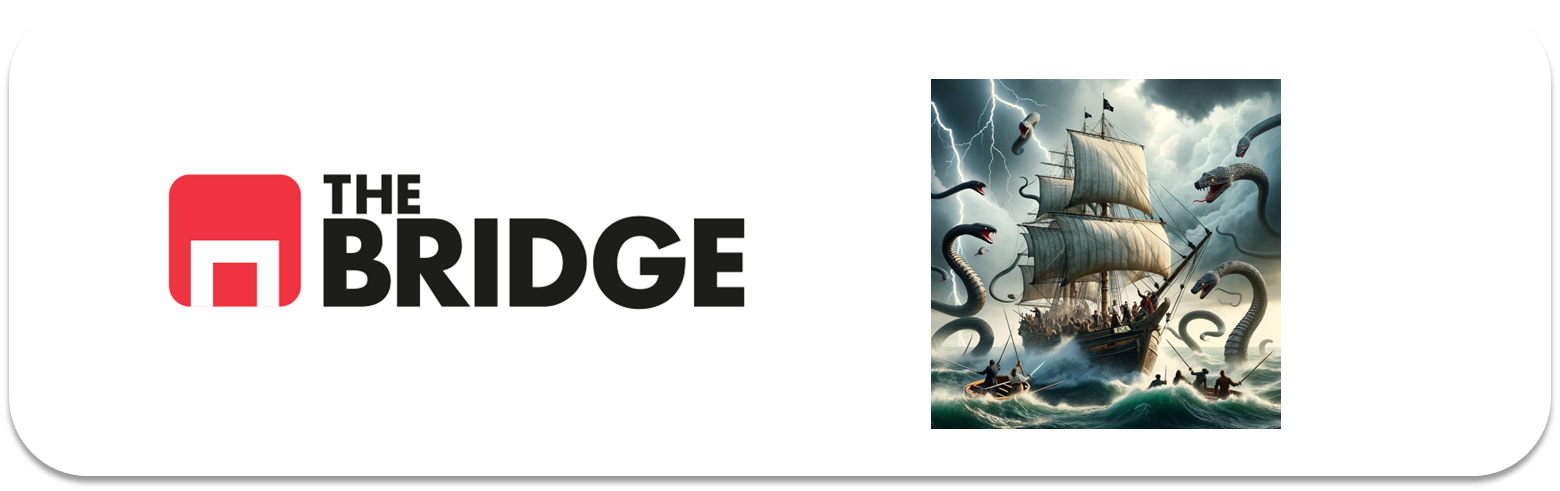

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descargar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [21]:
#Importamos las librerias:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from lightgbm import LGBMClassifier
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, SelectFromModel, RFE, SequentialFeatureSelector
from sklearn.metrics import mutual_info_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from xgboost import XGBClassifier

In [9]:
#Cargamos el dataset "credit scoring"
df_credito=pd.read_csv("./data/credit_npo.csv")

In [10]:
df_credito.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0


### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [11]:
df=df_credito.copy()

In [14]:
#Comprobamos variables con nulos (MonthlyIncome  y NumberOfDependents ):
df.isna().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [13]:
#Nos cargamos lon nulos:
df=df.dropna()

In [15]:
print(f"La longitud del dataset sin nulos es {len(df)}")

La longitud del dataset sin nulos es 11816


In [16]:
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0


In [19]:
#Sacamos la distribución de valores:

for col in df.columns:
    print(df[col].value_counts(normalize=True)*100)
    print("------------------------------------")


SeriousDlqin2yrs
0    92.975626
1     7.024374
Name: proportion, dtype: float64
------------------------------------
RevolvingUtilizationOfUnsecuredLines
0.000000    6.372715
1.000000    6.220379
0.155644    0.016926
0.095181    0.016926
0.443001    0.016926
              ...   
0.124904    0.008463
0.147695    0.008463
0.860370    0.008463
0.245543    0.008463
0.101002    0.008463
Name: proportion, Length: 10314, dtype: float64
------------------------------------
age
47     2.843602
49     2.699729
48     2.682803
50     2.513541
45     2.513541
         ...   
95     0.025389
94     0.016926
97     0.008463
96     0.008463
101    0.008463
Name: proportion, Length: 78, dtype: float64
------------------------------------
NumberOfTime30-59DaysPastDueNotWorse
0     83.090724
1     11.459039
2      3.359851
3      1.074814
4      0.541638
5      0.194651
6      0.169262
98     0.084631
8      0.016926
7      0.008463
Name: proportion, dtype: float64
------------------------------------
D

In [22]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [23]:
target="SeriousDlqin2yrs"

In [ ]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42) 

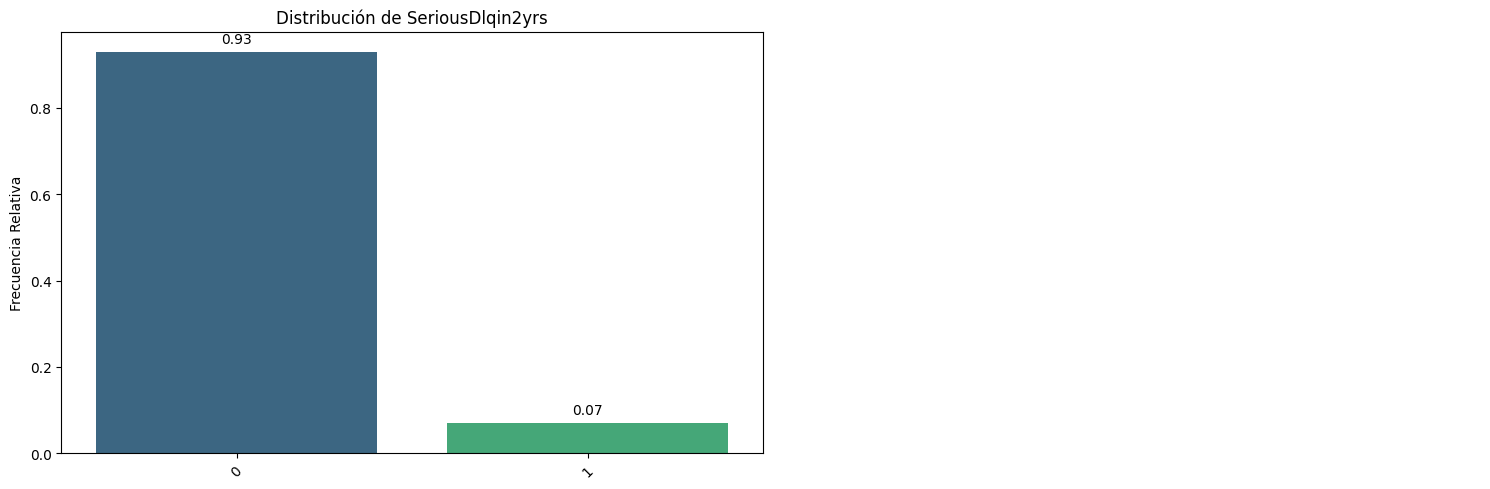

In [ ]:
bt.pinta_distribucion_categoricas(train_set, [target], True, True) #Ironicamente suele estar bastante desbalanceado

In [26]:
train_set.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,9452.0,0.070144,0.255403,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,9452.0,0.335207,0.362233,0.0,0.034869,0.179211,0.587533,6.0
age,9452.0,51.491536,14.499298,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,9452.0,0.343314,2.930489,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,9452.0,0.486047,2.505031,0.0,0.146204,0.297564,0.477876,96.0
MonthlyIncome,9452.0,6868.428058,12580.543336,0.0,3466.000000,5441.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,9452.0,8.794647,5.139555,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,9452.0,0.180279,2.889984,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,9452.0,1.064325,1.148156,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,9452.0,0.152772,2.870119,0.0,0.000000,0.000000,0.000000,98.0


In [ ]:
columnas_numberof = [col for col in df.columns if col.startswith("NumberOf")]
for col in columnas_numberof:
    distribucion_porcentaje = (df[col].value_counts(normalize= True, dropna= False).sort_index())
    
    porcentaje_ceros = distribucion_porcentaje.get(0, 0)
    print(f"\n{col} | valores_unicos =  {df[col].nunique()} | porcentaje_0 = {porcentaje_ceros:.2%}")
    print((distribucion_porcentaje.head(10) * 100).round(2))

In [ ]:
bt.plot_combined_graphs(df,

In [27]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [30]:
features_num=[
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfDependents",
    "NumberRealEstateLoansOrLines"]

In [31]:
df[features_num]

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfDependents,NumberRealEstateLoansOrLines
0,0.081892,37,0.070709,5656.0,12,0.0,0
1,0.023413,74,0.209197,4870.0,9,0.0,1
2,0.000000,43,0.080784,5000.0,2,2.0,0
3,0.492754,44,0.412735,7333.0,4,3.0,2
4,1.000000,63,0.000000,8333.0,3,1.0,0
...,...,...,...,...,...,...,...
12532,0.197116,59,0.290216,5140.0,6,0.0,1
12533,0.036726,62,0.884985,5833.0,12,0.0,1
12534,0.120313,49,0.577676,6333.0,7,2.0,2
12535,0.252566,63,0.037640,14000.0,9,1.0,0


In [33]:
df.head(5)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [32]:
# Me simplifico la vida con el nombre
n_corto = "NumberOfTime30-59DaysPastDueNotWorse"
# Método 1, con pd.cut
labels = [0,1,2] # Cambio 
train_set["N30-59"] = pd.cut(train_set[n_corto], bins = [-1,0,1,np.inf], labels = labels, right= True).astype(int) # right a True para incluir los valores "a la derecha" en el bin (es decir -1,0 incluye a todos los valores >-1 y <= 0)
test_set["N30-59"] = pd.cut(test_set[n_corto], bins = [-1,0,1,np.inf], labels = labels, right= True).astype(int) 
train_set["N30-59"].value_counts(True)

N30-59
0    0.831147
1    0.113521
2    0.055332
Name: proportion, dtype: float64

In [34]:
train_set["NumberOfTime60-89DaysPastDueNotWorse"] != 0

11145    False
2012     False
5428     False
12130    False
36       False
         ...  
11966    False
5512     False
5719     False
922      False
7727     False
Name: NumberOfTime60-89DaysPastDueNotWorse, Length: 9452, dtype: bool

In [53]:
train_set.drop(columns=["NumberOfTime30-59DaysPastDueNotWorse"], inplace=True)

In [38]:
train_set["N60-89"]=(train_set["NumberOfTime60-89DaysPastDueNotWorse"] != 0).astype(int)

In [45]:
train_set.drop(columns=["NumberOfTime60-89DaysPastDueNotWorse"], inplace=True)

In [50]:
train_set.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
       'NumberOfDependents', 'N30-59', 'N60-89', 'N90'],
      dtype='object')

In [48]:
train_set["N90"]=(train_set["NumberOfTimes90DaysLate"] != 0).astype(int)

In [49]:
train_set.drop(columns=["NumberOfTimes90DaysLate"], inplace=True)

In [41]:
len(features_num + [target])

8

In [43]:
train_set.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'N30-59', 'N60-89', 'N90'],
      dtype='object')

In [44]:
features_cat=["N30-59", "N60-89", "N90"]

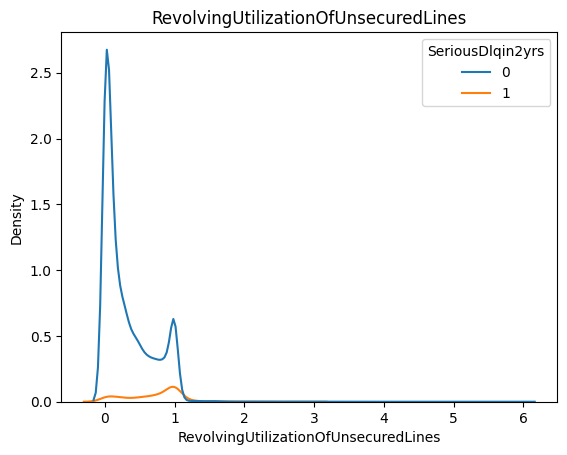

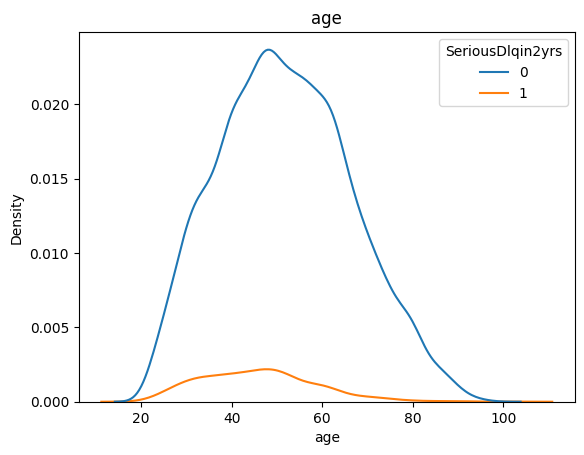

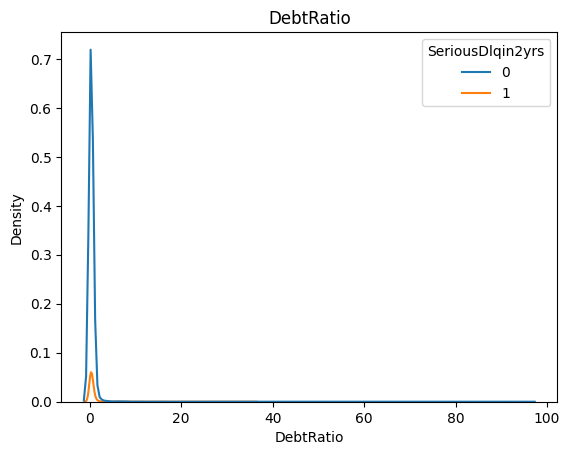

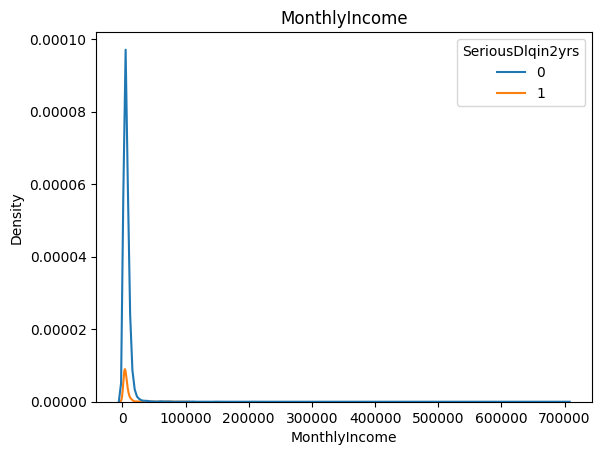

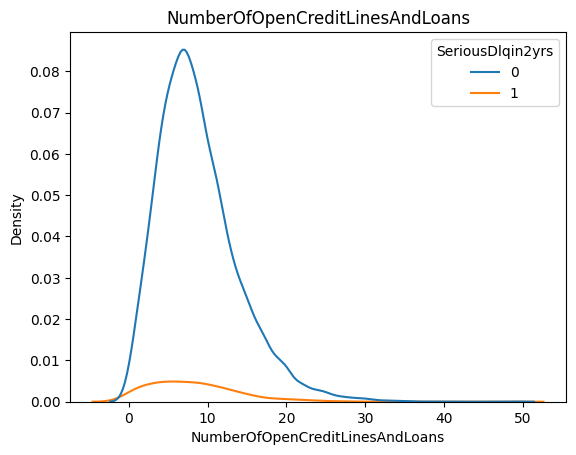

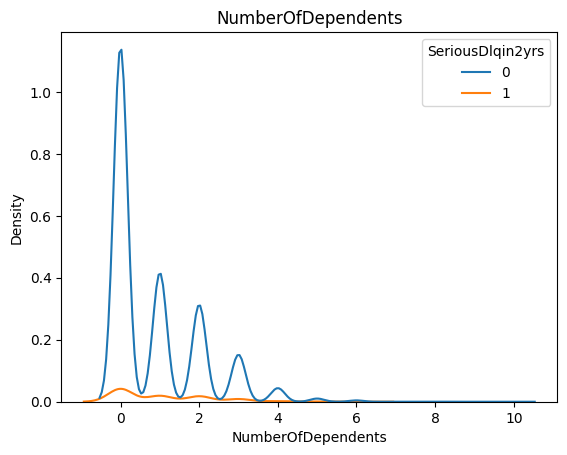

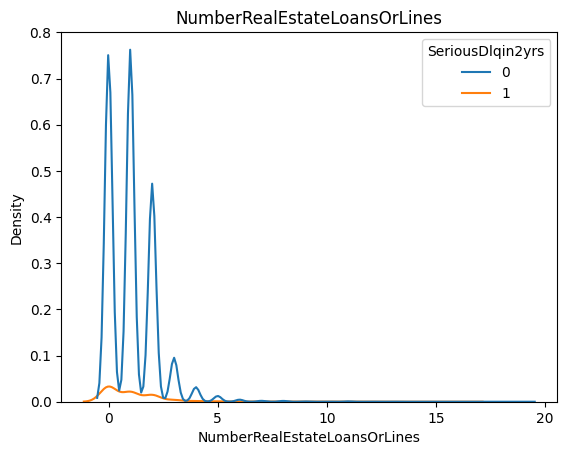

In [37]:
for col in features_num:
    if col != target:
        sns.kdeplot(df, x=col, hue=target)
        plt.title(col)
        plt.show()

In [51]:
train_set.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
       'NumberOfDependents', 'N30-59', 'N60-89', 'N90'],
      dtype='object')

In [55]:
#Codificación por conteo

In [54]:
#El selector de varianza cuando hay categóricas es peligroso

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.